**Edited by Shooq** 

In [7]:
import pandas as pd

In [12]:
df = pd.read_csv('/Users/shooqalzuhairi/Desktop/CDS2413 Programming/Data/synthetic_mental_health_dataset.csv')



In [13]:
df.rename(columns={
    'sleep_hours': 'Sleep_Hours',
    'screen_time': 'Screen_Time',
    'exercise_minutes': 'Exercise_Minutes',
    'daily_pending_tasks': 'Pending_Tasks',
    'interruptions': 'Interruptions',
    'fatigue_level': 'Fatigue_Level',
    'social_hours': 'Social_Hours',
    'coffee_cups': 'Coffee_Cups',
    'diet_quality': 'Diet_Quality',
    'weather': 'Weather',
    'mood_score': 'Mood_Score',
    'stress_level': 'Stress_Level'
}, inplace=True)


In [12]:
# descriptive Statistics for all columns
print(df.describe().T)   # T = Transpose


# create function to display descriptive statistics
def Desc_stat(ds, var):
    
    mean = ds[var].mean()
    median = ds[var].median()
    mode = ds[var].mode()[0]
    minimum = ds[var].min()
    maximum = ds[var].max()
    range_val = maximum - minimum
    std_dev = ds[var].std()
    variance = ds[var].var()
    skewness = ds[var].skew()
    kurtosis = ds[var].kurt()
    count = ds[var].count()
    
    
    Quart = [
        # Minimum
        ds[var].quantile(0),
        
        # 25th percentile
        ds[var].quantile(0.25),
        
        # Median
        ds[var].quantile(0.50),
        
        # 75th percentile
        ds[var].quantile(0.75),
        
        # Maximum
        ds[var].quantile(1),
        
        # Interquartile range (IQR)
        ds[var].quantile(0.75) - ds[var].quantile(0.25)
    ]
    
    
    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": range_val,
        "Std Dev": std_dev,
        "Variance": variance,
        "Skewness": skewness,
        "Kurtosis": kurtosis,
        "Minimum (0%)": Quart[0],
        "25th Percentile": Quart[1],
        "50th Percentile (Median)": Quart[2],
        "75th Percentile": Quart[3],
        "Maximum (100%)": Quart[4],
        "Interquartile Range (IQR)": Quart[5],
        "Count": count
    }
    
    return summary

                   count       mean        std       min       25%        50%  \
Sleep_Hours       2000.0   7.067237   1.481299  2.138099  6.066007   7.067037   
Screen_Time       2000.0   4.990009   2.002973  0.000000  3.581748   4.999893   
Exercise_Minutes  2000.0  19.868516  20.071066  0.004821  5.580022  13.289737   
Pending_Tasks     2000.0   2.948500   1.725206  0.000000  2.000000   3.000000   
Interruptions     2000.0   5.131000   2.278472  0.000000  3.000000   5.000000   
Fatigue_Level     2000.0   4.996769   2.000430  0.000000  3.647335   4.956565   
Social_Hours      2000.0   2.001369   0.959934  0.000000  1.304384   1.996521   
Coffee_Cups       2000.0   0.989500   1.012869  0.000000  0.000000   1.000000   
Mood_Score        2000.0   7.741658   2.023962  1.493465  6.090860   7.846064   
Stress_Level      2000.0   2.129647   1.482866  1.000000  1.000000   1.397094   

                        75%         max  
Sleep_Hours        8.024466   12.000000  
Screen_Time        6.331

In [13]:
# Random Sampling
sample = df.sample(n=150, random_state=1)

# Apply the descriptive function on the dependent variable
result = Desc_stat(sample, 'Stress_Level')

# Print the output
print("\nDescriptive Statistics for 'Stress_Level' (Random Sample of 150):\n")

for stat, value in result.items():
    print(f"{stat}: {value}")


Descriptive Statistics for 'Stress_Level' (Random Sample of 150):

Average: 2.2056496436926984
Median: 1.402482594253156
Mode: 1.0
Minimum: 1.0
Maximum: 7.924417511756866
Range: 6.924417511756866
Std Dev: 1.588434779317855
Variance: 2.523125048146563
Skewness: 1.4664460532051362
Kurtosis: 1.6530193763121535
Minimum (0%): 1.0
25th Percentile: 1.0
50th Percentile (Median): 1.402482594253156
75th Percentile: 2.963657640098296
Maximum (100%): 7.924417511756866
Interquartile Range (IQR): 1.9636576400982961
Count: 150


In [14]:
# Systematic Sampling
k = 5   # condition: select every 5th record
systematic_sample = df.iloc[::k]

# Apply the descriptive function on the dependent variable
result = Desc_stat(systematic_sample, 'Stress_Level')

# Print the output
print("\nDescriptive Statistics for 'Stress_Level' (Systematic Sample):\n")

for stat, value in result.items():
    print(f"{stat}: {value}")


Descriptive Statistics for 'Stress_Level' (Systematic Sample):

Average: 2.2455359745410046
Median: 1.4785784083265567
Mode: 1.0
Minimum: 1.0
Maximum: 9.684702456168132
Range: 8.684702456168132
Std Dev: 1.6008920810343126
Variance: 2.5628554551183718
Skewness: 1.4357060690410055
Kurtosis: 1.8562735996239592
Minimum (0%): 1.0
25th Percentile: 1.0
50th Percentile (Median): 1.4785784083265567
75th Percentile: 3.1384293393627485
Maximum (100%): 9.684702456168132
Interquartile Range (IQR): 2.1384293393627485
Count: 400


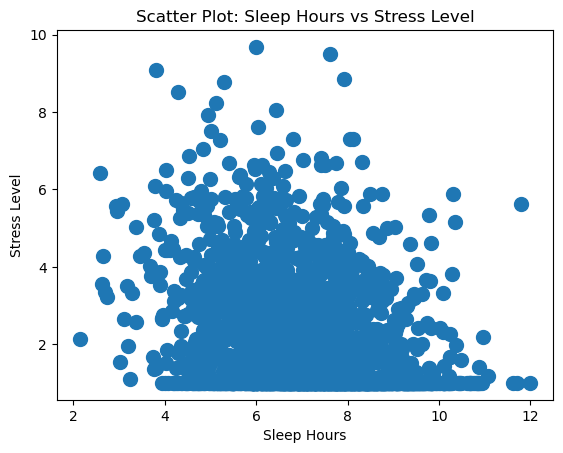

In [15]:
import matplotlib.pyplot as plt

# Scatter Plot: Sleep Hours vs Stress Level
df.plot.scatter(x='Sleep_Hours', y='Stress_Level', s=100);

plt.title("Scatter Plot: Sleep Hours vs Stress Level")
plt.xlabel("Sleep Hours")
plt.ylabel("Stress Level")

plt.show()

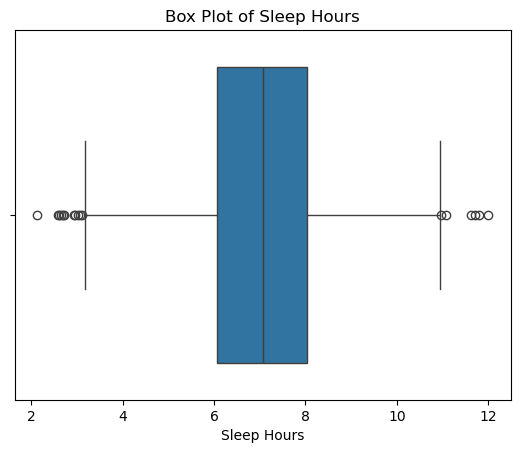

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# boxplot of Sleep Hours
sns.boxplot(x=df["Sleep_Hours"])

plt.xlabel('Sleep Hours')
plt.title("Box Plot of Sleep Hours")

plt.show()

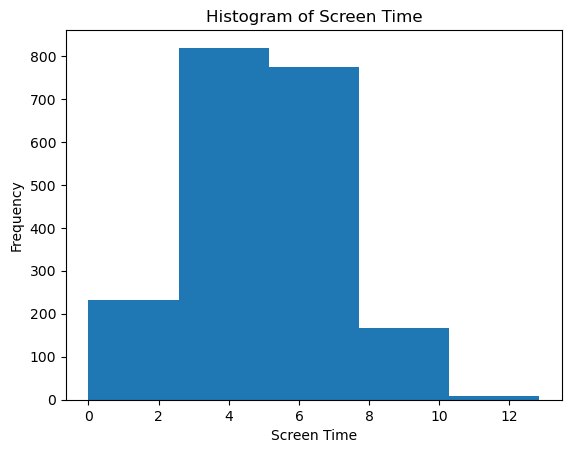

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix (numbers only)
corr = df.select_dtypes(include='number').corr()

# Create bigger figure (bigger squares)
plt.figure(figsize=(12, 10))

# Plot heatmap with smaller numbers
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={"size": 8})

plt.title("Correlation Heatmap")
plt.show()

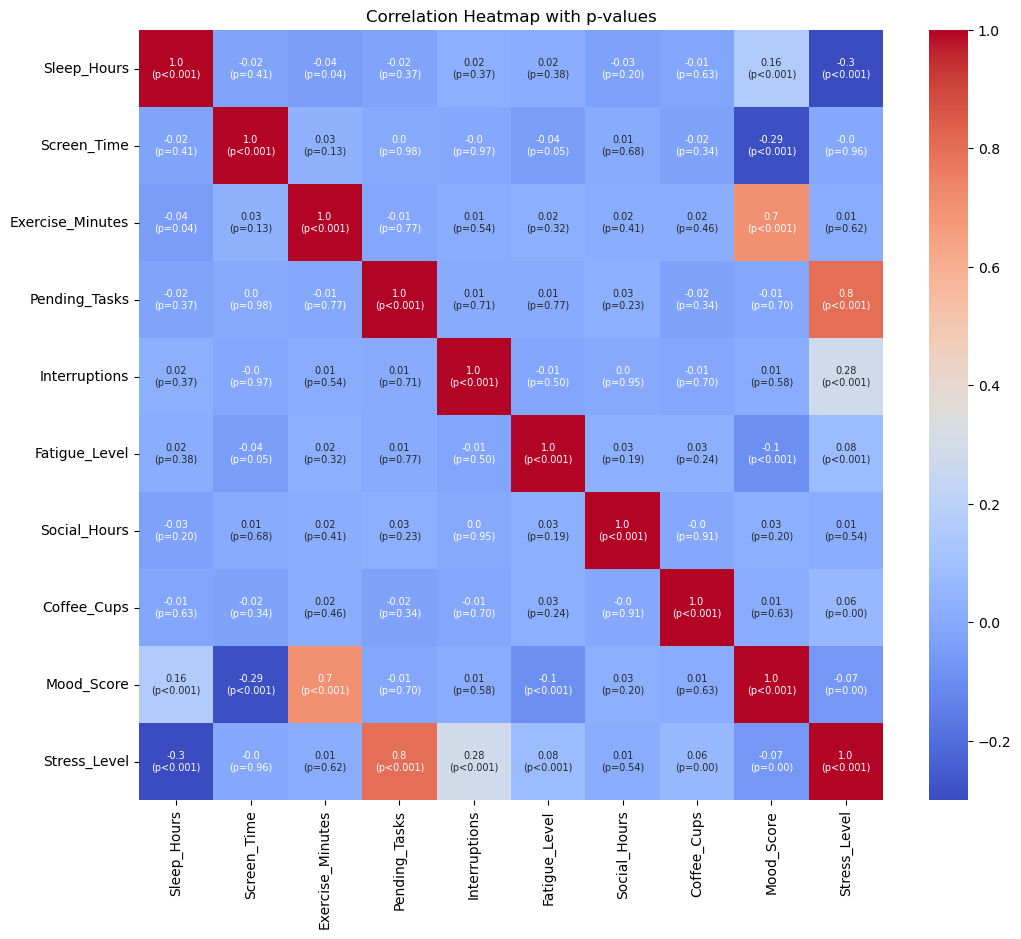

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

# Select numeric columns
df_num = df.select_dtypes(include='number')

# Create empty DataFrames
corr = df_num.corr()
pvals = pd.DataFrame(index=df_num.columns, columns=df_num.columns)

# Calculate p-values
for i in df_num.columns:
    for j in df_num.columns:
        _, p = pearsonr(df_num[i], df_num[j])
        pvals.loc[i, j] = p

# Function to shorten p-value
def format_p(p):
    if p < 0.001:
        return "p<0.001"
    else:
        return f"p={p:.2f}"

# Combine labels
labels = corr.round(2).astype(str)

for i in range(len(corr)):
    for j in range(len(corr)):
        labels.iloc[i, j] += "\n(" + format_p(float(pvals.iloc[i, j])) + ")"

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=labels, fmt='', cmap='coolwarm', annot_kws={"size": 7})

plt.title("Correlation Heatmap with p-values")
plt.show()

In [19]:
from scipy.stats import pearsonr

# Perform Pearson's Correlation Test
r, p_value = pearsonr(df['Sleep_Hours'], df['Stress_Level'])
df_pearson = len(df) - 2

# Print
print("Pearson's Correlation Test Results:")
print(f"1. Pearson's Correlation Coefficient (r): {r:.4f}")
print(f"2. P-Value: {p_value:.4f}")
print(f"3. Degrees of Freedom: {df_pearson}")

# Interpretation
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant correlation between Sleep Hours and Stress Level.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we accept the null hypothesis.")
    print("There is no statistically significant correlation between Sleep Hours and Stress Level.")

Pearson's Correlation Test Results:
1. Pearson's Correlation Coefficient (r): -0.3000
2. P-Value: 0.0000
3. Degrees of Freedom: 1998

Conclusion: Since the p-value is less than 0.05, we reject the null hypothesis.
There is a statistically significant correlation between Sleep Hours and Stress Level.


In [20]:
from scipy.stats import spearmanr

# Perform Spearman Correlation Test
r, p_value = spearmanr(df['Sleep_Hours'], df['Stress_Level'])
df_spearman = len(df) - 2

# Print
print("Spearman Correlation Test Results:")
print(f"1. Spearman Correlation Coefficient (r): {r:.4f}")
print(f"2. P-Value: {p_value:.4f}")
print(f"3. Degrees of Freedom: {df_spearman}")

# Interpretation
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant correlation between Sleep Hours and Stress Level.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we accept the null hypothesis.")
    print("There is no statistically significant correlation between Sleep Hours and Stress Level.")

Spearman Correlation Test Results:
1. Spearman Correlation Coefficient (r): -0.3228
2. P-Value: 0.0000
3. Degrees of Freedom: 1998

Conclusion: Since the p-value is less than 0.05, we reject the null hypothesis.
There is a statistically significant correlation between Sleep Hours and Stress Level.


In [21]:
from scipy.stats import chi2_contingency
import pandas as pd

# Convert Stress_Level into categories
df['Stress_Category'] = pd.cut(df['Stress_Level'], bins=3, labels=['Low', 'Medium', 'High'])

# Create contingency table
table = pd.crosstab(df['Weather'], df['Stress_Category'])

# Perform Chi-square test
chi2, p_value, dof, expected = chi2_contingency(table)

# Print
print("Chi-Square Test Results:")
print(f"1. Chi-Square Value: {chi2:.4f}")
print(f"2. P-Value: {p_value:.4f}")
print(f"3. Degrees of Freedom: {dof}")

# Interpretation
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant relationship between Weather and Stress Level.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we accept the null hypothesis.")
    print("There is no statistically significant relationship between Weather and Stress Level.")

Chi-Square Test Results:
1. Chi-Square Value: 3.8923
2. P-Value: 0.6913
3. Degrees of Freedom: 6

Conclusion: Since the p-value is greater than 0.05, we accept the null hypothesis.
There is no statistically significant relationship between Weather and Stress Level.


In [22]:
from scipy.stats import ttest_1samp

# One Sample T-test
# Assumption: population mean = 2 (you can change it)
# If p-value < 0.05 → reject the null hypothesis
# If p-value > 0.05 → accept the null hypothesis

t_stat, p_value = ttest_1samp(df['Stress_Level'], popmean=2)

# Print
print("One Sample T-test Results:")
print(f"1. T-Statistic: {t_stat:.4f}")
print(f"2. P-Value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("\nConclusion: Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("The sample mean is significantly different from the population mean.")
else:
    print("\nConclusion: Since the p-value is greater than 0.05, we accept the null hypothesis.")
    print("The sample mean is similar to the population mean.")

One Sample T-test Results:
1. T-Statistic: 3.9100
2. P-Value: 0.0001

Conclusion: Since the p-value is less than 0.05, we reject the null hypothesis.
The sample mean is significantly different from the population mean.
